In [1]:
import gifba
from scipy.integrate import solve_ivp
import numpy as np
import cobra as cb
import pandas as pd
from IPython.display import clear_output
import copy
import matplotlib.pyplot as plt
from cobra import Model
import os
import time
from tqdm import tqdm


In [2]:
# agora_dir_base = '/Users/david/Dropbox/My_Stuff/UVM_2/Lab/Projects/AGORA2_Metabolic_Models/'
agora_dir_base = "/home/rseag/AGORA2_Models/"
agora_dirs = ['AGORA2_annotatedMat_A_C', 'AGORA2_annotatedMat_D_F', 'AGORA2_annotatedMat_G_P', 'AGORA2_annotatedMat_R_Y']


In [ ]:
# store results in a pd df, store N models (model names too), N_unique rxns, sum(N_rxns per model), N unique metabolites, sum(N_metabolites per model)
results_df = pd.DataFrame(columns=["N_models", 
                                   "solver",
                                   "model_names", 
                                   "sum_N_rxns", 
                                   "sum_N_mets", 
                                   "gifba_solve_time", 
                                   "solve_ivp_time", 
                                   "gifba_fba_calls", 
                                   "dfba_fba_calls"])

# number of communities per N_models/solver combinations
n_reps = 3
N_models_list = [5, 10, 20]
solver_list = ['RK45', 'BDF']


In [3]:
# AGORA models
# Load N random models
N = 3

# count number of files in each directory
file_counts = []
for dir in agora_dirs:
    path = os.path.join(agora_dir_base, dir)
    count = len([name for name in os.listdir(path) if os.path.isfile(os.path.join(path, name))])
    file_counts.append(count)

# randomly select N models across all directories weighting by the number of files in each directory
selected_models = []
for i in range(N):
    # randomly select a directory based on file counts
    dir_index = np.random.choice(len(agora_dirs), p=np.array(file_counts)/sum(file_counts))
    dir = agora_dirs[dir_index]
    path = os.path.join(agora_dir_base, dir)
    
    # randomly select a model from the selected directory
    model_files = [name for name in os.listdir(path) if os.path.isfile(os.path.join(path, name))]
    model_file = np.random.choice(model_files)
    
    # load the model
    model_path = os.path.join(path, model_file)
    model = cb.io.load_matlab_model(model_path)
    
    selected_models.append(model)

Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01


No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


In [4]:
for i, model in enumerate(selected_models):
    for ex in model.exchanges:
        if "ex_biomass" in ex.id.lower():
            print(f"Model {i}: {model.id}, Biomass exchange: {ex.id}")

Model 0: model, Biomass exchange: EX_biomass(e)
Model 1: model, Biomass exchange: EX_biomass(e)
Model 2: model, Biomass exchange: EX_biomass(e)


In [5]:
def rename_community_biomass(models, old_biomass_id="EX_Bio(e)"):
    """
    Renames the biomass exchange reactions and their associated metabolites 
    to track individual species separately.
    """
    # Deepcopy ensures we don't accidentally modify the original template models
    updated_models = copy.deepcopy(models)
    
    for idx, model in enumerate(updated_models):
        suffix = f"_{idx + 1}"  # e.g., _1, _2
        
        if old_biomass_id in model.reactions:
            # 1. Isolate the biomass reaction
            biomass_rxn = model.reactions.get_by_id(old_biomass_id)
            
            # 2. Rename the associated biomass metabolite(s) FIRST
            # We cast to list() to avoid modifying a dictionary while iterating over it
            for metabolite in list(biomass_rxn.metabolites):
                metabolite.id = f"{metabolite.id}{suffix}"
                # Optional: update the metabolite name for clarity
                metabolite.name = f"{metabolite.name} (Species {idx + 1})"
            
            # 3. Rename the reaction itself
            biomass_rxn.id = f"{old_biomass_id}{suffix}"
            biomass_rxn.name = f"{biomass_rxn.name} (Species {idx + 1})"
            
    return updated_models

In [6]:
renamed_models = rename_community_biomass(selected_models, old_biomass_id="EX_biomass(e)")

Read LP format model from file /tmp/tmp3k5k4goa.lp
Reading time = 0.00 seconds
: 1283 rows, 2568 columns, 10784 nonzeros
Read LP format model from file /tmp/tmpuy789ke_.lp
Reading time = 0.00 seconds
: 909 rows, 1864 columns, 8058 nonzeros
Read LP format model from file /tmp/tmp67l20lxj.lp
Reading time = 0.00 seconds
: 952 rows, 2216 columns, 9400 nonzeros


In [7]:
# Initialize giFBA object
# assigne equal relative abundance to each model
rel_abund = np.ones(N) / N

# define medium

euro_media = "../Examples/2_real_models/data/euro_diet.tsv"
euro_media = pd.read_csv(euro_media, sep="\t", header=0, index_col=0).to_dict()
euro_media = euro_media["Flux Value"]
euro_media = {ex.replace("[e]", "(e)"): -flux for ex, flux in euro_media.items()}

community = gifba.gifbaObject(renamed_models, [euro_media, 0.1], # minimal media
                            rel_abund=rel_abund)

Read LP format model from file /tmp/tmpkqa8aobc.lp
Reading time = 0.00 seconds
: 1283 rows, 2568 columns, 10784 nonzeros
Read LP format model from file /tmp/tmpi9_mx3rf.lp
Reading time = 0.00 seconds
: 909 rows, 1864 columns, 8058 nonzeros
Read LP format model from file /tmp/tmp6h43rz6i.lp
Reading time = 0.00 seconds
: 952 rows, 2216 columns, 9400 nonzeros


giFBA run time: 25.74 seconds


In [ ]:
def dsdt(t, S, models, vmax, km, media_keys):
    # Initialize the rate of change for each metabolite to 0
    dsdt_rates = np.zeros(len(S))
    
    # Create a mapping for quick lookup: {metabolite_id: current_concentration}
    conc_map = dict(zip(media_keys, S))
    
    for mdl_idx, model in enumerate(models):
        # 1. Update lower bounds based on Michaelis-Menten kinetics
        for ex_id in media_keys:
            if ex_id in model.reactions and "bio" not in ex_id:
                v_max = vmax.loc[str(mdl_idx), ex_id]
                k_m = km.loc[str(mdl_idx), ex_id]
                c = conc_map[ex_id]
                
                if c < 1e-6:
                    c = 0.0  # Avoid very small concentrations causing numerical errors

                # Michaelis-Menten uptake limit 
                uptake_limit = (v_max * c) / (k_m + c) # (mmol/(gi*hr))
                
                # In COBRA, uptake is negative, so lower_bound is -uptake_limit
                model.reactions.get_by_id(ex_id).lower_bound = -uptake_limit

        # 2. Run FBA
        solution = model.optimize()

        # 3. Add fluxes to the net rate of change (weighted by clamped relative abundance)
        if solution.status == 'optimal':
            for i, ex_id in enumerate(media_keys):
                flux_per_hr = solution.fluxes.get(ex_id, 0)
                
                # We add the RATE of change to our array. solve_ivp handles the integration over time.
                dsdt_rates[i] += flux_per_hr * rel_abund[mdl_idx]

    # 4. Add media fluxes to rate of change
    for i, ex_id in enumerate(media_keys):
        media_flux = community.env_fluxes.loc[0, ex_id]
        dsdt_rates[i] += media_flux 

    return dsdt_rates


# Optimized Tracker (progress bar, dsdt caller, early stopping)
class dFBATracker:
    def __init__(self, t_start, t_end, tol=1e-5):
        self.pbar = tqdm(total=t_end - t_start, desc="Simulating ODE")
        self.highest_t = t_start
        self.tol = tol
        
        # State caching to prevent re-evaluating FBA
        self.prev_t = None
        self.prev_dsdt = None
        self.curr_t = None
        self.curr_dsdt = None

    def ode_wrapper(self, t, S, *args):
        # Calculate rates once per solver step
        rates = dsdt(t, S, *args)
        
        # Update progress bar only on forward progress
        if t > self.highest_t:
            self.pbar.update(t - self.highest_t)
            self.highest_t = t
        
        # Cache the history. We only save a "previous" state if dt is large enough.
        # This ignores the tiny perturbation steps BDF takes for Jacobian estimation.
        if self.curr_t is None or abs(t - self.curr_t) > 1e-4:
            self.prev_t = self.curr_t
            self.prev_dsdt = self.curr_dsdt
            
        self.curr_t = t
        self.curr_dsdt = rates
        
        return rates

    def check_stop_condition(self, t, S, *args):
        # Prevent stopping before we have enough history
        if self.prev_t is None or self.prev_dsdt is None:
            return 1.0  
            
        # If the solver is evaluating the exact time we just cached, reuse it! (Saves FBA calculation)
        if t == self.curr_t:
            current_rates = self.curr_dsdt
        else:
            current_rates = dsdt(t, S, *args)
            
        dt = t - self.prev_t
        if abs(dt) < 1e-6:
            return 1.0
            
        max_accel = np.max(np.abs(current_rates - self.prev_dsdt)) / abs(dt)
        
        # Event triggers when this drops below tolerance (direction=-1)
        return max_accel - self.tol


In [ ]:
start_time = time.time()
env_flux, org_flux = community.run_gifba(n_iterations=100, method="pfba", verbose=False)
end_time = time.time()
print(f"giFBA run time: {end_time - start_time:.2f} seconds")

# equal rel_abund
rel_abund = community.rel_abund.copy()

# media from gifba
substrate_0 = community.env_fluxes.loc[0, :].to_dict()

# kinetic params
V_MAX_ALL = 100  # (mmol/(gi*hr)) Maximum uptake rate for all substrates
K_M_ALL = 0.1  # (mmol) Michaelis-Menten constant for all substrates
vmax_vals = pd.DataFrame(np.full((len(renamed_models), len(substrate_0.keys())), V_MAX_ALL),
                              columns=list(substrate_0.keys()),
                              index=[str(mdl_idx) for mdl_idx in range(len(renamed_models))])
km_vals = pd.DataFrame(np.full((len(renamed_models), len(substrate_0.keys())), K_M_ALL),
                              columns=list(substrate_0.keys()),
                              index=[str(mdl_idx) for mdl_idx in range(len(renamed_models))])

# Preparing cleaner inputs for solve_ivp
m_keys = list(substrate_0.keys()) 
m_vals = np.array([substrate_0[k] for k in m_keys]) 
y0 = np.zeros(len(m_vals))  

# solve_ivp time
t_start, t_end = 0, 100
t_span = (t_start, t_end)

# Initialize the tracker
tracker = dFBATracker(t_start=t_start, t_end=t_end, tol=)

# Create a standalone wrapper function for the event
def steady_state_event(t, S, *args):
    return tracker.check_stop_condition(t, S, *args)

# Configure solve_ivp's event system on the standalone function
steady_state_event.terminal = True
steady_state_event.direction = -1  # Trigger only when dropping from > tol to < tol

time_start = time.time()
# Run the solver
sol = solve_ivp(
    tracker.ode_wrapper,  
    t_span=t_span,
    y0=y0,
    args=(copy.deepcopy(renamed_models), vmax_vals, km_vals, m_keys),
    method='RK45', 
    events=[steady_state_event]  
)
time_end = time.time()
print(f"ODE solver run time: {time_end - time_start:.2f} seconds")
print("Success:", sol.success)
print("Status:", sol.status)
print("Message:", sol.message)
print("Termination time (actual t_span):", sol.t[-1] if len(sol.t) > 0 else "No steps taken")

In [7]:
# print(m_keys)
for i, metabolite in enumerate(m_keys):
    if "bio" in metabolite.lower():
        print(f"Biomass metabolite found: {metabolite} at index {i}")

Biomass metabolite found: EX_Bio(e)_2 at index 0
Biomass metabolite found: EX_Bio(e)_1 at index 2


Min: 0.0
Max: 9.37048441954389
Min: 0.0
Max: 7.93193520130437
Min: 0.0
Max: 16.508942121615


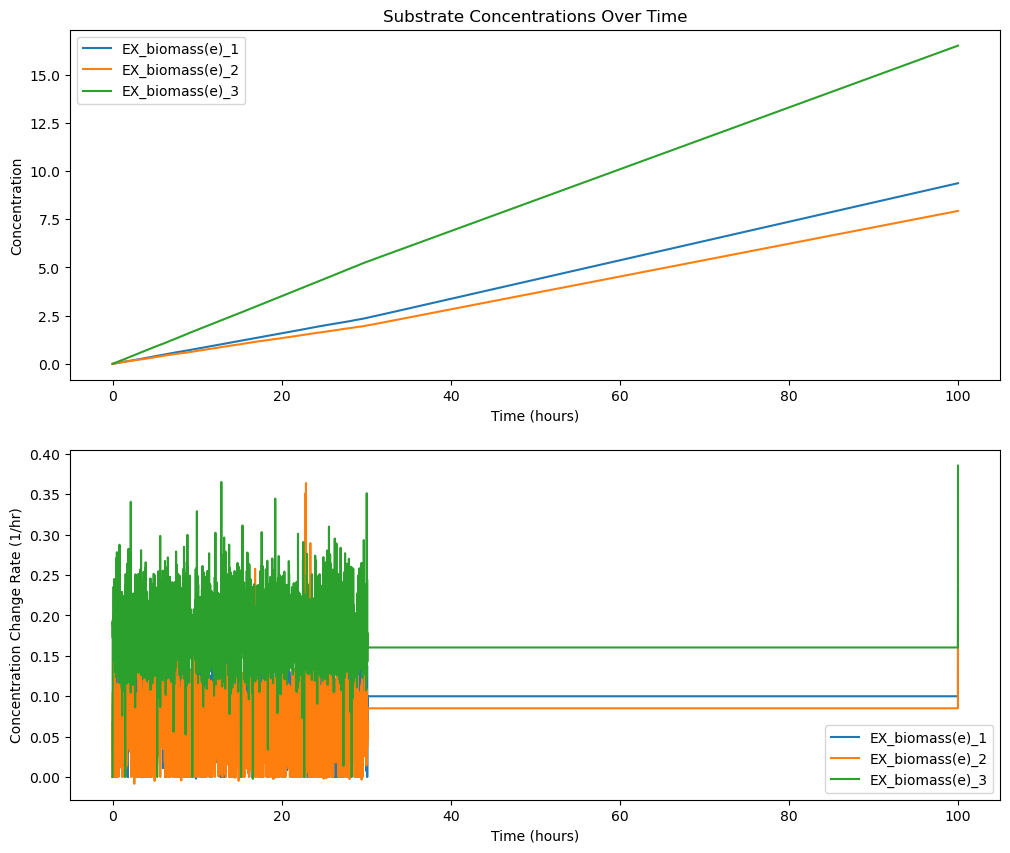

In [20]:
# plot each metabolite's concentration over time
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=False)
for i, metabolite in enumerate(m_keys):
    if "bio" in metabolite.lower():
        print("Min:", np.min(sol.y[i]))
        print("Max:", np.max(sol.y[i]))
        # plot slope of biomass concentrations over time
        slope = np.gradient(sol.y[i], sol.t)
        accel = np.gradient(slope, sol.t)
        # plotting = accel/slope
        ax[1].plot(sol.t, slope, label=metabolite)
        ax[1].set_xlabel('Time (hours)')
        ax[1].set_ylabel('Concentration Change Rate (1/hr)')
        ax[1].legend()
        accel = np.gradient(slope, sol.t)
        

        #ax[1].plot(sol.t, sol.y[i], label=metabolite)
        #ax[1].set_xlabel('Time (hours)')
        #ax[1].set_ylabel('Concentration')
        #ax[1].set_title('Biomass Concentrations Over Time')
        #ax[1].legend()
    # else:
        ax[0].plot(sol.t, sol.y[i], label=metabolite)
        ax[0].set_xlabel('Time (hours)')
        ax[0].set_ylabel('Concentration')
        ax[0].set_title('Substrate Concentrations Over Time')
        ax[0].legend()